# SIT720 — 11.1 HD Task: Machine Learning Mini Research
## Option 3: An efficient stacking-based ensemble technique for early heart attack prediction

**Selected paper:** M. Bhagat, A. Sharma, and P. Agarwal, “An efficient stacking-based ensemble technique for early heart attack prediction,” *Multimedia Tools and Applications*, vol. 84, pp. 36351–36375, 2025.


This notebook implements the complete reproduction and the proposed extension. It deliberately separates the **paper-style reproduction** from the **leakage-aware proposed study** so that the effect of duplicate leakage can be measured rather than hidden.



## 1. Paper facts and published reference results

The paper reports 1,025 observations, 14 columns in the experimental dataset, 13 predictors and a binary target. The six individual classifiers are Logistic Regression, Decision Tree, Random Forest, XGBoost, Naive Bayes and KNN. The proposed paper method is a 5-fold stacking ensemble with a meta-classifier.

The paper reports the following values in Table 11: LR (Accuracy 0.8439, Precision 0.8196, Recall 0.9090, F1 0.8620, AUC 0.9204); NB (0.8439, 0.8250, 0.9000, 0.8608, 0.9185); KNN (0.8585, 0.8648, 0.8727, 0.8687, 0.9304); DT (0.9268, 0.9702, 0.8909, 0.9289, 0.9702); RF (0.9268, 0.9130, 0.9545, 0.9333, 0.9734); XGB (0.9073, 0.9174, 0.9090, 0.9132, 0.9830); and the stacking model (0.9853, 1.0000, 0.9727, 0.9861, 0.9880).

The paper also contains conflicting accuracy statements elsewhere: XGBoost is described once as 93.17% and elsewhere as 90.73%, while stacking is described once as 96.58% and elsewhere as 98.53%. These inconsistencies are treated as findings to analyse, not corrected.


## 2. Experimental strategy

### Part 1 — faithful reproduction
The published dataset is kept intact for the paper-style experiment, including duplicate records, because removing rows would no longer reproduce the published data configuration. The same 13 predictors are used. Because the paper does not fully specify the split seed or all classifier hyperparameters, this notebook makes explicit assumptions: stratified 80:20 train/test split, seed 42, median imputation, standardisation, library-default model settings unless a paper-specific setting is reported, and a 5-fold stacking model with logistic-regression meta-classifier.

### Part 2 — leakage-aware proposed solution
The main limitation investigated is exact duplicate leakage. The dataset audit identifies duplicates before modelling, but the paper does not report a duplicate-control protocol. The proposed study therefore removes exact duplicates **before** splitting, converts the documented anomalous codes `ca=4` and `thal=0` to missing values, treats categorical predictors as categorical, and evaluates a stability-selected heterogeneous soft-voting ensemble. The experimental protocol also uses repeated stratified holdout evaluations and a paired Wilcoxon signed-rank test as empirical evidence.

The proposed contribution is therefore the **whole leakage-aware learning protocol**, rather than simply changing one classifier: data-integrity control + domain-aware preprocessing + stability-oriented feature selection + tuned heterogeneous probability ensemble + repeated evaluation.


In [1]:
# Optional installation — run once if needed.
# %pip install -r requirements.txt

import sys, os, json, warnings, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, matthews_corrcoef, classification_report
)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from scipy.stats import wilcoxon, mannwhitneyu, t as student_t

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

SEED = 42
TEST_SIZE = 0.20
FEATURES = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal"]
TARGET = "target"
CAT_FEATURES = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]
NUM_FEATURES = ["age","trestbps","chol","thalach","oldpeak"]
RESULTS_DIR = Path("results"); FIGURES_DIR = Path("figures")
RESULTS_DIR.mkdir(exist_ok=True); FIGURES_DIR.mkdir(exist_ok=True)
print("Python:", sys.version)
print("XGBoost available:", XGBOOST_AVAILABLE)


Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
XGBoost available: True


In [2]:
# Dataset input
DATA_PATH = Path("heart.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "heart.csv is required. Place the actual dataset used for the paper beside this notebook."
    )

df = pd.read_csv(DATA_PATH)
missing_columns = [c for c in FEATURES + [TARGET] if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df[FEATURES + [TARGET]].copy()
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
if df[TARGET].isna().any():
    raise ValueError("Target contains non-numeric or missing values.")
df[TARGET] = df[TARGET].astype(int)
print("Shape:", df.shape)
display(df.head())


Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Data audit — this is intentionally performed before any cleaning.
audit = pd.DataFrame({
    "Measure": [
        "Rows", "Columns", "Predictors", "Missing cells", "Exact duplicate rows",
        "Unique rows", "Class 0", "Class 1", "ca=4 records", "thal=0 records"
    ],
    "Value": [
        len(df), df.shape[1], len(FEATURES), int(df[FEATURES].isna().sum().sum()),
        int(df.duplicated().sum()), int(df.drop_duplicates().shape[0]),
        int((df[TARGET]==0).sum()), int((df[TARGET]==1).sum()),
        int((df["ca"]==4).sum()), int((df["thal"]==0).sum())
    ]
})
display(audit)
audit.to_csv(RESULTS_DIR/"data_audit.csv", index=False)


,Measure,Value
0,Rows,1025
1,Columns,14
2,Predictors,13
3,Missing cells,0
4,Exact duplicate rows,723
5,Unique rows,302
6,Class 0,499
7,Class 1,526
8,ca=4 records,18
9,thal=0 records,7


In [4]:
# Duplicate leakage diagnostic.
# A feature duplicate is dangerous when one copy is in train and another is in test.
X_all = df[FEATURES].copy(); y_all = df[TARGET].copy()
Xtr_a, Xte_a, ytr_a, yte_a = train_test_split(X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=SEED)
train_keys = set(map(tuple, Xtr_a.to_numpy()))
test_duplicate_mask = Xte_a.apply(tuple, axis=1).isin(train_keys)
feature_duplicates_across_split = int(test_duplicate_mask.sum())

feature_target_conflicts = (
    df.groupby(FEATURES, dropna=False)[TARGET].nunique().reset_index(name="n_targets")
)
conflicting_groups = int((feature_target_conflicts["n_targets"] > 1).sum())

leakage_audit = pd.DataFrame({
    "Measure": [
        "Exact duplicate rows in full data",
        "Unique rows after deduplication",
        "Test rows with identical predictor vector present in training set",
        "Duplicate predictor groups with conflicting targets"
    ],
    "Value": [int(df.duplicated().sum()), int(df.drop_duplicates().shape[0]), feature_duplicates_across_split, conflicting_groups]
})
display(leakage_audit)
leakage_audit.to_csv(RESULTS_DIR/"duplicate_leakage_audit.csv", index=False)


,Measure,Value
0,Exact duplicate rows in full data,723
1,Unique rows after deduplication,302
2,Test rows with identical predictor vector pres...,202
3,Duplicate predictor groups with conflicting ta...,0


# PART 1 — Reproduction of the published study

In [5]:
# Published Table 11 values used only as the reference benchmark.
published = pd.DataFrame([
    ["Logistic Regression",0.8439,0.8196,0.9090,0.8620,0.9204],
    ["Naive Bayes",0.8439,0.8250,0.9000,0.8608,0.9185],
    ["KNN",0.8585,0.8648,0.8727,0.8687,0.9304],
    ["Decision Tree",0.9268,0.9702,0.8909,0.9289,0.9702],
    ["Random Forest",0.9268,0.9130,0.9545,0.9333,0.9734],
    ["XGBoost",0.9073,0.9174,0.9090,0.9132,0.9830],
    ["Stacking",0.9853,1.0000,0.9727,0.9861,0.9880]
], columns=["Model","Accuracy","Precision","Recall","F1","AUC"])
display(published)
published.to_csv(RESULTS_DIR/"published_table11.csv", index=False)


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8439,0.8196,0.9090,0.8620,0.9204
1,Naive Bayes,0.8439,0.8250,0.9000,0.8608,0.9185
2,KNN,0.8585,0.8648,0.8727,0.8687,0.9304
3,Decision Tree,0.9268,0.9702,0.8909,0.9289,0.9702
4,Random Forest,0.9268,0.9130,0.9545,0.9333,0.9734
5,XGBoost,0.9073,0.9174,0.9090,0.9132,0.9830
6,Stacking,0.9853,1.0000,0.9727,0.9861,0.9880


In [6]:
# Paper-style preprocessing assumption.
# The publication states that missing values are handled and numerical values are standardised.
# It also states that categorical variables are encoded, but does not specify the exact encoder.
# For the faithful reproduction, the encoded integer columns are retained as numeric predictors,
# while imputation and standardisation are performed inside the pipeline to prevent fold leakage.
paper_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X = df[FEATURES].copy(); y = df[TARGET].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)
print("Paper-style train/test:", X_train.shape, X_test.shape)


Paper-style train/test: (820, 13) (205, 13)


In [7]:
if not XGBOOST_AVAILABLE:
    raise ImportError("XGBoost is required for faithful reproduction of the six classifiers. Install xgboost and rerun.")

baseline_models = {
    "Logistic Regression": Pipeline([("prep", clone(paper_preprocessor)), ("model", LogisticRegression(max_iter=3000, random_state=SEED))]),
    "Decision Tree": Pipeline([("prep", clone(paper_preprocessor)), ("model", DecisionTreeClassifier(random_state=SEED))]),
    "Random Forest": Pipeline([("prep", clone(paper_preprocessor)), ("model", RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=1))]),
    "XGBoost": Pipeline([("prep", clone(paper_preprocessor)), ("model", XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=SEED, n_jobs=1))]),
    "Naive Bayes": Pipeline([("prep", clone(paper_preprocessor)), ("model", GaussianNB())]),
    "KNN": Pipeline([("prep", clone(paper_preprocessor)), ("model", KNeighborsClassifier())])
}


In [8]:
def evaluate_model(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_eval)[:,1]
    else:
        score = model.decision_function(X_eval)
    cm = confusion_matrix(y_eval, pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval,pred),
        "Precision": precision_score(y_eval,pred,zero_division=0),
        "Recall": recall_score(y_eval,pred,zero_division=0),
        "F1": f1_score(y_eval,pred,zero_division=0),
        "AUC": roc_auc_score(y_eval,score),
        "Specificity": specificity,
        "MCC": matthews_corrcoef(y_eval,pred),
        "TN": tn,"FP": fp,"FN": fn,"TP": tp
    }, pred, score

fitted_baselines={}; rows=[]; baseline_predictions={}; baseline_scores={}
for name, model in baseline_models.items():
    model.fit(X_train,y_train)
    fitted_baselines[name]=model
    row,pred,score=evaluate_model(name,model,X_test,y_test)
    rows.append(row); baseline_predictions[name]=pred; baseline_scores[name]=score
reproduction_individual = pd.DataFrame(rows)
display(reproduction_individual.round(4))


,Model,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC,TN,FP,FN,TP
0,Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298,0.70,0.6309,70,30,9,96
1,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857,1.00,0.9712,100,0,3,102
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,100,0,0,105
3,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,100,0,0,105
4,Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043,0.78,0.6602,78,22,13,92
5,KNN,0.8634,0.8738,0.8571,0.8654,0.9629,0.87,0.7269,87,13,15,90


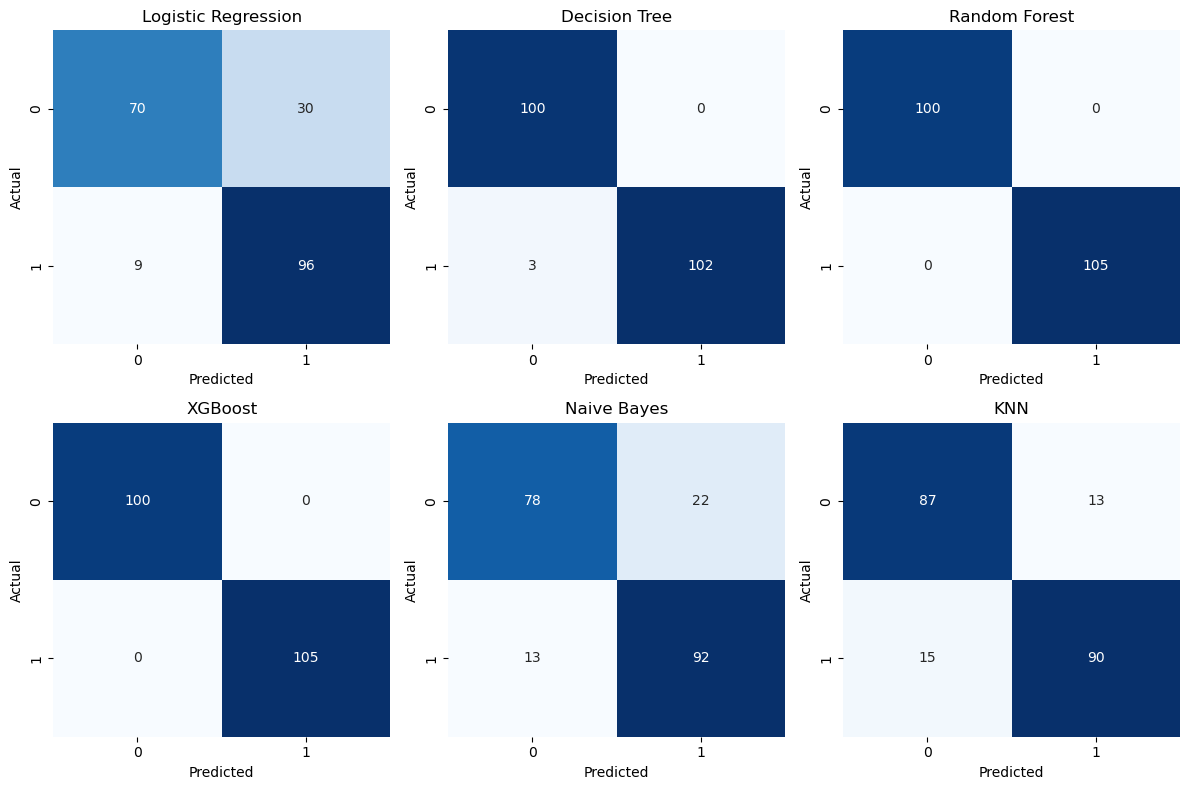

In [9]:
# Confusion matrices for all six individual models.
fig, axes = plt.subplots(2,3,figsize=(12,8))
for ax,(name,pred) in zip(axes.ravel(), baseline_predictions.items()):
    sns.heatmap(confusion_matrix(y_test,pred,labels=[0,1]),annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.savefig(FIGURES_DIR/"reproduction_confusion_matrices.png",dpi=220,bbox_inches="tight"); plt.show()


In [10]:
# Published 5-fold stacking reproduction.
stack_estimators=[(k,clone(v)) for k,v in baseline_models.items()]
stack = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=3000, random_state=SEED),
    cv=5, stack_method="predict_proba", passthrough=False, n_jobs=1
)
stack.fit(X_train,y_train)
stack_row, stack_pred, stack_score = evaluate_model("Stacking",stack,X_test,y_test)
reproduction = pd.concat([reproduction_individual,pd.DataFrame([stack_row])],ignore_index=True)
display(reproduction.round(4))
reproduction.to_csv(RESULTS_DIR/"paper_style_reproduction_metrics.csv",index=False)


,Model,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC,TN,FP,FN,TP
0,Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298,0.70,0.6309,70,30,9,96
1,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857,1.00,0.9712,100,0,3,102
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,100,0,0,105
3,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,100,0,0,105
4,Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043,0.78,0.6602,78,22,13,92
5,KNN,0.8634,0.8738,0.8571,0.8654,0.9629,0.87,0.7269,87,13,15,90
6,Stacking,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,100,0,0,105


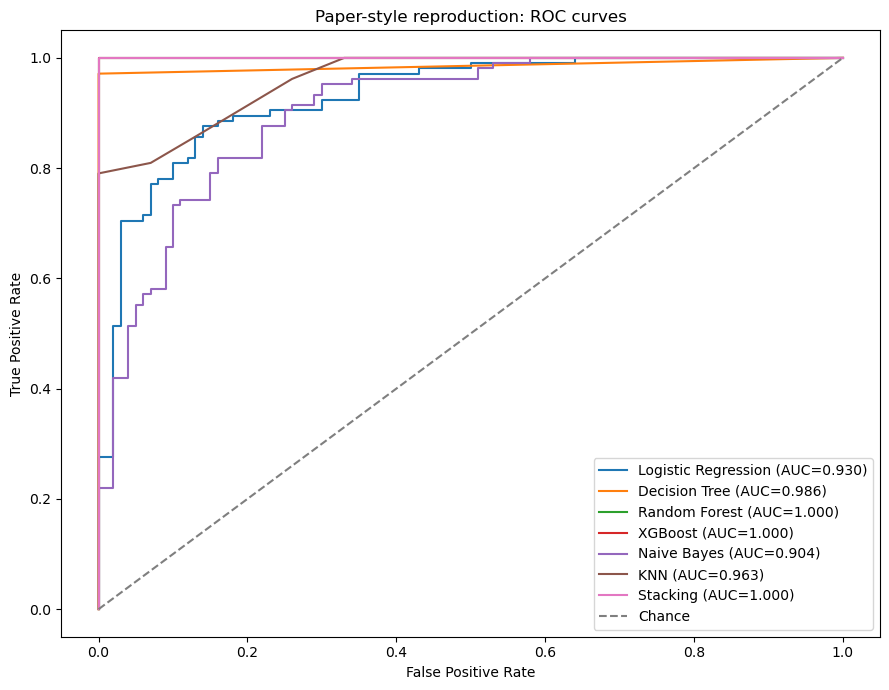

In [11]:
# ROC curves for all seven reproduced models.
plt.figure(figsize=(9,7))
for name,score in {**baseline_scores,"Stacking":stack_score}.items():
    fpr,tpr,_=roc_curve(y_test,score)
    auc=roc_auc_score(y_test,score)
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"--",label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("Paper-style reproduction: ROC curves")
plt.legend(); plt.tight_layout(); plt.savefig(FIGURES_DIR/"paper_style_roc.png",dpi=220,bbox_inches="tight"); plt.show()


In [12]:
# Published-vs-reproduced comparison.
repro_map=reproduction.set_index("Model")
pub_map=published.set_index("Model")
rows=[]
for m in published["Model"]:
    actual_name="Stacking" if m=="Stacking" else m
    r=repro_map.loc[actual_name]
    p=pub_map.loc[m]
    rows.append({"Model":m,"Published_Accuracy":p.Accuracy,"Reproduced_Accuracy":r.Accuracy,"Delta_Accuracy":r.Accuracy-p.Accuracy,
                 "Published_Precision":p.Precision,"Reproduced_Precision":r.Precision,
                 "Published_Recall":p.Recall,"Reproduced_Recall":r.Recall,
                 "Published_F1":p.F1,"Reproduced_F1":r.F1,
                 "Published_AUC":p.AUC,"Reproduced_AUC":r.AUC})
published_vs_reproduced=pd.DataFrame(rows)
display(published_vs_reproduced.round(4))
published_vs_reproduced.to_csv(RESULTS_DIR/"published_vs_reproduced.csv",index=False)


,Model,Published_Accuracy,Reproduced_Accuracy,Delta_Accuracy,Published_Precision,Reproduced_Precision,Published_Recall,Reproduced_Recall,Published_F1,Reproduced_F1,Published_AUC,Reproduced_AUC
0,Logistic Regression,0.8439,0.8098,-0.0341,0.8196,0.7619,0.9090,0.9143,0.8620,0.8312,0.9204,0.9298
1,Naive Bayes,0.8439,0.8293,-0.0146,0.8250,0.8070,0.9000,0.8762,0.8608,0.8402,0.9185,0.9043
2,KNN,0.8585,0.8634,0.0049,0.8648,0.8738,0.8727,0.8571,0.8687,0.8654,0.9304,0.9629
3,Decision Tree,0.9268,0.9854,0.0586,0.9702,1.0000,0.8909,0.9714,0.9289,0.9855,0.9702,0.9857
4,Random Forest,0.9268,1.0000,0.0732,0.9130,1.0000,0.9545,1.0000,0.9333,1.0000,0.9734,1.0000
5,XGBoost,0.9073,1.0000,0.0927,0.9174,1.0000,0.9090,1.0000,0.9132,1.0000,0.9830,1.0000
6,Stacking,0.9853,1.0000,0.0147,1.0000,1.0000,0.9727,1.0000,0.9861,1.0000,0.9880,1.0000


In [13]:
# Internal consistency check using the confusion-matrix counts shown in Fig. 5 of the paper.
# The figure reports TN=95, FP=0, FN=3 and TP=107 for the proposed stacking model.
# Recomputing the metrics from those counts exposes inconsistencies in Table 11/Table 12.

TN, FP, FN, TP = 95, 0, 3, 107
cm_total = TN + FP + FN + TP
paper_fig5_metrics = {
    "Accuracy": (TP + TN) / cm_total,
    "Precision": TP / (TP + FP),
    "Recall/Sensitivity": TP / (TP + FN),
    "F1": 2 * TP / (2 * TP + FP + FN),
    "Specificity": TN / (TN + FP),
    "MCC": (TP*TN - FP*FN) / np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
}
paper_fig5_check = pd.DataFrame([paper_fig5_metrics])
display(paper_fig5_check.round(4))

paper_consistency_note = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall/Sensitivity", "F1", "Specificity", "MCC"],
    "Figure_5_recomputed": [paper_fig5_metrics["Accuracy"], paper_fig5_metrics["Precision"], paper_fig5_metrics["Recall/Sensitivity"], paper_fig5_metrics["F1"], paper_fig5_metrics["Specificity"], paper_fig5_metrics["MCC"]],
    "Table_11_or_12_reported": [0.9853, 1.0000, 0.9727, 0.9861, 0.9861, 1.0000],
    "Difference": [paper_fig5_metrics["Accuracy"]-0.9853, paper_fig5_metrics["Precision"]-1.0, paper_fig5_metrics["Recall/Sensitivity"]-0.9727, paper_fig5_metrics["F1"]-0.9861, paper_fig5_metrics["Specificity"]-0.9861, paper_fig5_metrics["MCC"]-1.0]
})
display(paper_consistency_note.round(4))
paper_consistency_note.to_csv(RESULTS_DIR/"paper_metric_consistency_check.csv",index=False)


,Accuracy,Precision,Recall/Sensitivity,F1,Specificity,MCC
0,0.9854,1.0,0.9727,0.9862,1.0,0.9711


,Metric,Figure_5_recomputed,Table_11_or_12_reported,Difference
0,Accuracy,0.9854,0.9853,0.0001
1,Precision,1.0000,1.0000,0.0000
2,Recall/Sensitivity,0.9727,0.9727,0.0000
3,F1,0.9862,0.9861,0.0001
4,Specificity,1.0000,0.9861,0.0139
5,MCC,0.9711,1.0000,-0.0289


## 3. Critical analysis of the reproduction

The key diagnostic is not whether the reproduction reaches 98.53%. The stronger question is whether the evaluation protocol permits exact duplicates to cross the train/test boundary. If identical predictor rows occur in both sets, the test set is no longer independent at the row level. This is particularly important for tree ensembles and stacking because a model can learn an identical feature vector during training and then encounter the same vector in testing.

The notebook therefore reports the number of duplicated predictor vectors crossing the split. This observation is then carried into Part 2 rather than being treated as an incidental data-cleaning detail. The paper-style result remains the faithful reproduction; the leakage-aware result is the methodological correction.


# PART 2 — Proposed leakage-aware machine-learning solution

In [14]:
# Clean the data for the proposed protocol only.
clean_df = df.drop_duplicates().reset_index(drop=True).copy()
clean_df.loc[clean_df["ca"]==4,"ca"] = np.nan
clean_df.loc[clean_df["thal"]==0,"thal"] = np.nan

print("Original rows:",len(df))
print("Rows after exact deduplication:",len(clean_df))
print("Rows removed:",len(df)-len(clean_df))
print("Invalid ca codes converted to NaN:",int((df["ca"]==4).sum()))
print("Invalid thal codes converted to NaN:",int((df["thal"]==0).sum()))


Original rows: 1025
Rows after exact deduplication: 302
Rows removed: 723
Invalid ca codes converted to NaN: 18
Invalid thal codes converted to NaN: 7


In [15]:
# Leakage-aware split.
Xc=clean_df[FEATURES].copy(); yc=clean_df[TARGET].copy()
Xc_train,Xc_test,yc_train,yc_test=train_test_split(Xc,yc,test_size=TEST_SIZE,stratify=yc,random_state=SEED)
print(Xc_train.shape,Xc_test.shape)


(241, 13) (61, 13)


In [16]:
# Domain-aware preprocessing: categorical variables are one-hot encoded and continuous variables are scaled.
onehot=OneHotEncoder(handle_unknown="ignore", sparse_output=False)
clean_preprocessor=ColumnTransformer([
    ("num",Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())]),NUM_FEATURES),
    ("cat",Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",onehot)]),CAT_FEATURES)
],remainder="drop")


## 4. Stability-oriented feature selection

A single fixed L1 selector is replaced by a stability-oriented selection step. The selector repeatedly fits an L1 logistic model on stratified subsamples of the training data and records how often each transformed feature receives a non-zero coefficient. A feature is retained only when its selection frequency reaches the chosen threshold. This makes the feature-selection decision depend on repeated training subsets rather than one fitted model, and it remains inside the pipeline so the test set cannot influence selection.


In [17]:
class StabilitySelector(BaseEstimator, TransformerMixin):
    def __init__(self, C=0.5, frequency_threshold=0.60, n_repeats=5, random_state=42):
        self.C=C; self.frequency_threshold=frequency_threshold; self.n_repeats=n_repeats; self.random_state=random_state
    def fit(self,X,y):
        X=np.asarray(X); y=np.asarray(y)
        rng=np.random.RandomState(self.random_state)
        selected_counts=np.zeros(X.shape[1],dtype=float)
        for r in range(self.n_repeats):
            skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=int(rng.randint(0,1_000_000)))
            train_idx,_=next(skf.split(X,y))
            model=LogisticRegression(penalty="l1",solver="liblinear",C=self.C,max_iter=3000,random_state=self.random_state)
            model.fit(X[train_idx],y[train_idx])
            selected_counts += (np.abs(model.coef_[0])>1e-8)
        self.selection_frequency_=selected_counts/self.n_repeats
        self.support_=self.selection_frequency_>=self.frequency_threshold
        if self.support_.sum()==0:
            self.support_[np.argmax(self.selection_frequency_)]=True
        return self
    def transform(self,X):
        return np.asarray(X)[:,self.support_]
    def get_support(self): return self.support_


In [18]:
def proposed_pipeline(model):
    return Pipeline([
        ("prep",clone(clean_preprocessor)),
        ("select",StabilitySelector(random_state=SEED)),
        ("model",model)
    ])

proposed_spaces={
    "Logistic Regression":(proposed_pipeline(LogisticRegression(max_iter=3000,random_state=SEED)),
        {"select__C":[0.1,0.5,1.0],"select__frequency_threshold":[0.50,0.60,0.70],"model__C":[0.1,1,10]}),
    "RBF-SVM":(proposed_pipeline(SVC(probability=True,random_state=SEED)),
        {"select__C":[0.1,0.5,1.0],"select__frequency_threshold":[0.50,0.60,0.70],"model__C":[0.5,1,10],"model__gamma":["scale","auto"]}),
    "Random Forest":(proposed_pipeline(RandomForestClassifier(random_state=SEED,n_jobs=1)),
        {"select__C":[0.1,0.5,1.0],"select__frequency_threshold":[0.50,0.60,0.70],"model__n_estimators":[200,400],"model__max_depth":[None,5,10],"model__max_features":["sqrt","log2"]}),
    "KNN":(proposed_pipeline(KNeighborsClassifier()),
        {"select__C":[0.1,0.5,1.0],"select__frequency_threshold":[0.50,0.60,0.70],"model__n_neighbors":[3,5,7,9],"model__weights":["uniform","distance"]})
}


In [19]:
# Tune on the training partition only. Randomized search samples 30 configurations per model family.
# The search space is deliberately broader than a token hyperparameter change and includes
# the stability selector itself. All tuning remains inside the training partition.
tuning_cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
tuned={}; tuning_rows=[]
for name,(estimator,grid) in proposed_spaces.items():
    search=RandomizedSearchCV(estimator,grid,scoring="f1",cv=tuning_cv,n_iter=30,random_state=SEED,n_jobs=-1,refit=True)
    search.fit(Xc_train,yc_train)
    tuned[name]=search.best_estimator_
    tuning_rows.append({"Model":name,"Best_CV_F1":search.best_score_,"Configurations_sampled":30,"Best_parameters":str(search.best_params_)})
tuning_summary=pd.DataFrame(tuning_rows)
display(tuning_summary.round(4))
tuning_summary.to_csv(RESULTS_DIR/"proposed_tuning_summary.csv",index=False)


,Model,Best_CV_F1,Configurations_sampled,Best_parameters
0,Logistic Regression,0.8802,30,"{'select__frequency_threshold': 0.5, 'select__..."
1,RBF-SVM,0.8866,30,"{'select__frequency_threshold': 0.6, 'select__..."
2,Random Forest,0.8697,30,"{'select__frequency_threshold': 0.5, 'select__..."
3,KNN,0.8626,30,"{'select__frequency_threshold': 0.7, 'select__..."


In [20]:
# Proposed heterogeneous soft-voting ensemble.
voting=VotingClassifier([
    ("lr",tuned["Logistic Regression"]),
    ("svm",tuned["RBF-SVM"]),
    ("rf",tuned["Random Forest"]),
    ("knn",tuned["KNN"])
],voting="soft",n_jobs=1)
voting.fit(Xc_train,yc_train)
proposed_row,proposed_pred,proposed_score=evaluate_model("Proposed LASSE",voting,Xc_test,yc_test)
proposed_metrics=pd.DataFrame([proposed_row])
display(proposed_metrics.round(4))
proposed_metrics.to_csv(RESULTS_DIR/"proposed_metrics.csv",index=False)


,Model,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC,TN,FP,FN,TP
0,Proposed LASSE,0.8197,0.8235,0.8485,0.8358,0.8907,0.7857,0.6363,22,6,5,28


In [21]:
# Leakage-aware stacking baseline: same architecture as the paper, but on the cleaned data with
# invalid-code handling and categorical-aware preprocessing. This isolates the contribution of the protocol.
clean_stack_estimators=[]
for name,model in [
    ("lr",LogisticRegression(max_iter=3000,random_state=SEED)),
    ("dt",DecisionTreeClassifier(random_state=SEED)),
    ("rf",RandomForestClassifier(n_estimators=100,random_state=SEED,n_jobs=1)),
    ("nb",GaussianNB()),
    ("knn",KNeighborsClassifier())
]:
    clean_stack_estimators.append((name,Pipeline([("prep",clone(clean_preprocessor)),("model",model)])))
if XGBOOST_AVAILABLE:
    clean_stack_estimators.append(("xgb",Pipeline([("prep",clone(clean_preprocessor)),("model",XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=SEED,n_jobs=1))])))
clean_stack=StackingClassifier(clean_stack_estimators,final_estimator=LogisticRegression(max_iter=3000,random_state=SEED),cv=5,stack_method="predict_proba",n_jobs=1)
clean_stack.fit(Xc_train,yc_train)
clean_stack_row,clean_stack_pred,clean_stack_score=evaluate_model("Leakage-aware stacking",clean_stack,Xc_test,yc_test)
display(pd.DataFrame([clean_stack_row]).round(4))


  File "c:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Admin\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\anaconda3\Lib\subprocess.

,Model,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC,TN,FP,FN,TP
0,Leakage-aware stacking,0.8197,0.8438,0.8182,0.8308,0.8896,0.8214,0.6382,23,5,6,27


In [22]:
# Fair ablation: retain the same four-model soft-voting architecture but remove ONLY the stability selector.
# Each model is retuned on the same training partition, so the comparison isolates the contribution
# of stability selection rather than simultaneously changing the model family and tuning protocol.
no_select_spaces={
    "Logistic Regression":(Pipeline([("prep",clone(clean_preprocessor)),("model",LogisticRegression(max_iter=3000,random_state=SEED))]),
        {"model__C":[0.1,0.5,1,10]}),
    "RBF-SVM":(Pipeline([("prep",clone(clean_preprocessor)),("model",SVC(probability=True,random_state=SEED))]),
        {"model__C":[0.1,0.5,1,10],"model__gamma":["scale","auto"]}),
    "Random Forest":(Pipeline([("prep",clone(clean_preprocessor)),("model",RandomForestClassifier(random_state=SEED,n_jobs=1))]),
        {"model__n_estimators":[200,400],"model__max_depth":[None,5,10],"model__max_features":["sqrt","log2"]}),
    "KNN":(Pipeline([("prep",clone(clean_preprocessor)),("model",KNeighborsClassifier())]),
        {"model__n_neighbors":[3,5,7,9],"model__weights":["uniform","distance"]})
}
no_select_tuned={}; no_select_rows=[]
for name,(estimator,grid) in no_select_spaces.items():
    search=RandomizedSearchCV(estimator,grid,scoring="f1",cv=tuning_cv,n_iter=min(30, np.prod([len(v) for v in grid.values()])),random_state=SEED,n_jobs=-1,refit=True)
    search.fit(Xc_train,yc_train)
    no_select_tuned[name]=search.best_estimator_
    no_select_rows.append({"Model":name,"Best_CV_F1":search.best_score_,"Best_parameters":str(search.best_params_)})
no_select_voting=VotingClassifier([
    ("lr",no_select_tuned["Logistic Regression"]),
    ("svm",no_select_tuned["RBF-SVM"]),
    ("rf",no_select_tuned["Random Forest"]),
    ("knn",no_select_tuned["KNN"])
],voting="soft",n_jobs=1)
no_select_voting.fit(Xc_train,yc_train)
abl_row,abl_pred,abl_score=evaluate_model("Ablation: same voting without stability selection",no_select_voting,Xc_test,yc_test)
ablation=pd.DataFrame([abl_row])
display(ablation.round(4))
ablation.to_csv(RESULTS_DIR/"fair_ablation_metrics.csv",index=False)


,Model,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC,TN,FP,FN,TP
0,Ablation: same voting without stability selection,0.8197,0.8438,0.8182,0.8308,0.8939,0.8214,0.6382,23,5,6,27


In [23]:
# Final test comparison on the same leakage-aware holdout.
comparison_clean=pd.DataFrame([clean_stack_row,proposed_row,abl_row])
display(comparison_clean[["Model","Accuracy","Precision","Recall","F1","AUC","Specificity","MCC"]].round(4))
comparison_clean.to_csv(RESULTS_DIR/"clean_protocol_comparison.csv",index=False)


,Model,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC
0,Leakage-aware stacking,0.8197,0.8438,0.8182,0.8308,0.8896,0.8214,0.6382
1,Proposed LASSE,0.8197,0.8235,0.8485,0.8358,0.8907,0.7857,0.6363
2,Ablation: same voting without stability selection,0.8197,0.8438,0.8182,0.8308,0.8939,0.8214,0.6382


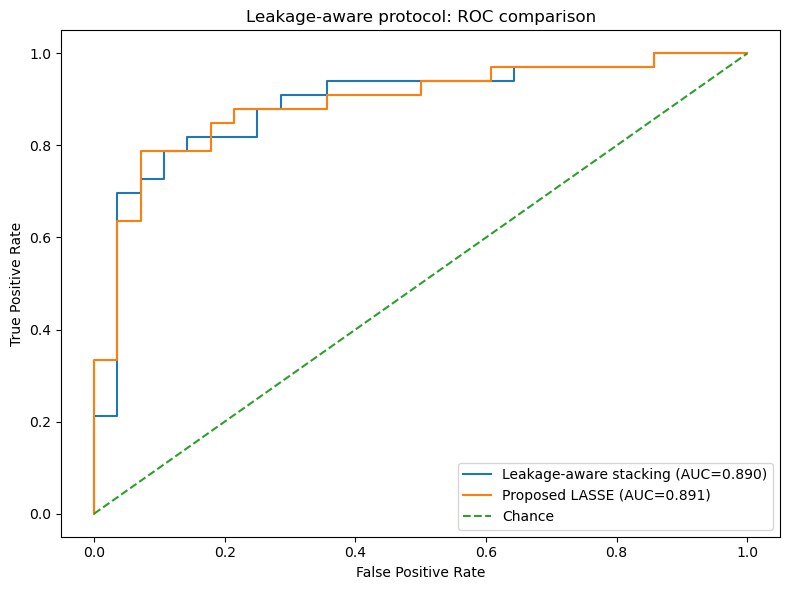

In [24]:
# Proposed ROC comparison.
plt.figure(figsize=(8,6))
for name,score,yv in [("Leakage-aware stacking",clean_stack_score,yc_test),("Proposed LASSE",proposed_score,yc_test)]:
    fpr,tpr,_=roc_curve(yv,score); auc=roc_auc_score(yv,score); plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"--",label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("Leakage-aware protocol: ROC comparison")
plt.legend(); plt.tight_layout(); plt.savefig(FIGURES_DIR/"clean_protocol_roc.png",dpi=220,bbox_inches="tight"); plt.show()


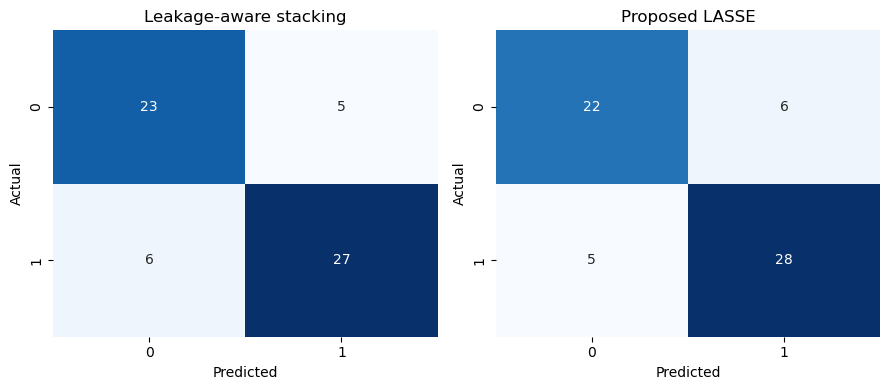

In [25]:
# Confusion matrices for the clean stacking baseline and proposed model.
fig,axes=plt.subplots(1,2,figsize=(9,4))
for ax,(title,pred) in zip(axes,[
    ("Leakage-aware stacking",clean_stack_pred),
    ("Proposed LASSE",proposed_pred)
]):
    sns.heatmap(confusion_matrix(yc_test,pred,labels=[0,1]),annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.savefig(FIGURES_DIR/"clean_protocol_confusion_matrices.png",dpi=220,bbox_inches="tight"); plt.show()


## 5. Repeated evaluation and statistical evidence

The primary clean holdout is complemented by ten repeated stratified 80:20 holdouts. Crucially, the proposed model is **retuned inside each training partition**. No hyperparameters selected on the seed-42 split are reused in another repetition. This nested repeated-holdout design prevents the test partitions from influencing model selection and directly addresses the evaluation-leakage concern identified in Part 1.

The same leakage-aware stacking baseline is refitted for every seed. For LASSE, the full stability-selection and hyperparameter search are repeated inside the training data. For the repeated clean-data model comparison, paired Wilcoxon signed-rank and Nadeau–Bengio corrected resampled t-tests are reported as complementary evidence. The separate matched paper-style versus leakage-aware comparison uses an unpaired Mann–Whitney U test because the two protocols operate on different row-level datasets; neither analysis is interpreted as proof of clinical generalisation.


In [26]:
def build_clean_stacking(seed):
    stack_estimators=[
        ("lr",Pipeline([("prep",clone(clean_preprocessor)),("model",LogisticRegression(max_iter=3000,random_state=seed))])),
        ("dt",Pipeline([("prep",clone(clean_preprocessor)),("model",DecisionTreeClassifier(random_state=seed))])),
        ("rf",Pipeline([("prep",clone(clean_preprocessor)),("model",RandomForestClassifier(n_estimators=100,random_state=seed,n_jobs=1))])),
        ("nb",Pipeline([("prep",clone(clean_preprocessor)),("model",GaussianNB())])),
        ("knn",Pipeline([("prep",clone(clean_preprocessor)),("model",KNeighborsClassifier())]))
    ]
    if XGBOOST_AVAILABLE:
        stack_estimators.append(("xgb",Pipeline([("prep",clone(clean_preprocessor)),("model",XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=seed,n_jobs=1))])))
    return StackingClassifier(stack_estimators,final_estimator=LogisticRegression(max_iter=3000,random_state=seed),cv=5,stack_method="predict_proba",n_jobs=1)

def tune_lasse_for_seed(Xtr,ytr,seed):
    local_spaces={}
    for name,(estimator,grid) in proposed_spaces.items():
        local_spaces[name]=(clone(estimator),grid)
    local_tuned={}
    local_cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=seed)
    for name,(estimator,grid) in local_spaces.items():
        search=RandomizedSearchCV(estimator,grid,scoring="f1",cv=local_cv,n_iter=15,random_state=seed,n_jobs=-1,refit=True)
        search.fit(Xtr,ytr)
        local_tuned[name]=search.best_estimator_
    local_voting=VotingClassifier([
        ("lr",local_tuned["Logistic Regression"]),
        ("svm",local_tuned["RBF-SVM"]),
        ("rf",local_tuned["Random Forest"]),
        ("knn",local_tuned["KNN"])
    ],voting="soft",n_jobs=1)
    return local_voting

repeat_rows=[]
for seed in range(10):
    Xtr,Xte,ytr,yte=train_test_split(Xc,yc,test_size=TEST_SIZE,stratify=yc,random_state=seed)
    s=build_clean_stacking(seed)
    v=tune_lasse_for_seed(Xtr,ytr,seed)
    s.fit(Xtr,ytr); v.fit(Xtr,ytr)
    rs,_,_=evaluate_model("Leakage-aware stacking",s,Xte,yte)
    rv,_,_=evaluate_model("Proposed LASSE",v,Xte,yte)
    repeat_rows.append({"Seed":seed,"Stacking_Accuracy":rs["Accuracy"],"Proposed_Accuracy":rv["Accuracy"],
                        "Stacking_F1":rs["F1"],"Proposed_F1":rv["F1"],"Stacking_AUC":rs["AUC"],"Proposed_AUC":rv["AUC"]})
repeated=pd.DataFrame(repeat_rows)
display(repeated.round(4))
repeated.to_csv(RESULTS_DIR/"repeated_holdout_results.csv",index=False)


,Seed,Stacking_Accuracy,Proposed_Accuracy,Stacking_F1,Proposed_F1,Stacking_AUC,Proposed_AUC
0,0,0.9016,0.8852,0.9091,0.8923,0.9329,0.9361
1,1,0.8852,0.8852,0.8889,0.8889,0.9513,0.9535
2,2,0.9016,0.8852,0.9091,0.8986,0.9372,0.9232
3,3,0.7541,0.8361,0.7945,0.8529,0.8539,0.8896
4,4,0.9508,0.9344,0.9565,0.9412,0.9924,0.9892
5,5,0.8525,0.8525,0.8657,0.8696,0.9210,0.8983
6,6,0.8197,0.8197,0.8308,0.8358,0.8842,0.8842
7,7,0.8197,0.7869,0.8358,0.8000,0.8918,0.8810
8,8,0.8197,0.7705,0.8308,0.7742,0.9080,0.8874
9,9,0.7869,0.7869,0.8116,0.8060,0.8366,0.8344


In [27]:
# Mean ± SD, paired Wilcoxon tests, and Nadeau–Bengio corrected resampled t-tests.
def corrected_resampled_t_test(a,b,test_size=TEST_SIZE):
    # a and b are paired scores from repeated random train/test splits.
    d=np.asarray(b)-np.asarray(a)
    n=len(d)
    mean_d=d.mean()
    s2=d.var(ddof=1)
    corrected_var=(1/n + test_size/(1-test_size))*s2
    se=np.sqrt(corrected_var)
    t_stat=mean_d/se if se>0 else np.nan
    p=2*student_t.sf(abs(t_stat),df=n-1) if np.isfinite(t_stat) else np.nan
    return t_stat,p

summary_rows=[]
for metric in ["Accuracy","F1","AUC"]:
    a=repeated[f"Stacking_{metric}"]; b=repeated[f"Proposed_{metric}"]
    try:
        wstat,wp=wilcoxon(b,a,alternative="two-sided")
    except ValueError:
        wstat,wp=np.nan,np.nan
    tstat,tp=corrected_resampled_t_test(a,b)
    summary_rows.append({"Metric":metric,"Stacking_mean":a.mean(),"Stacking_SD":a.std(ddof=1),"Proposed_mean":b.mean(),"Proposed_SD":b.std(ddof=1),"Wilcoxon_stat":wstat,"Wilcoxon_p":wp,"NB_corrected_t":tstat,"NB_corrected_p":tp})
statistical_summary=pd.DataFrame(summary_rows)
display(statistical_summary.round(4))
statistical_summary.to_csv(RESULTS_DIR/"statistical_comparison.csv",index=False)


,Metric,Stacking_mean,Stacking_SD,Proposed_mean,Proposed_SD,Wilcoxon_stat,Wilcoxon_p,NB_corrected_t,NB_corrected_p
0,Accuracy,0.8492,0.0603,0.8443,0.0537,6.0,0.4062,-0.2402,0.8155
1,F1,0.8633,0.0514,0.8559,0.0521,12.0,0.2500,-0.4142,0.6885
2,AUC,0.9109,0.0464,0.9077,0.0438,14.5,0.3750,-0.3323,0.7473


In [28]:
# Matched ten-seed comparison of the paper-style and leakage-aware protocols.
# The same ten random seeds are used for both protocols so the headline difference is not
# based on comparing a single seed-42 result with a multi-seed average.
def build_paper_stacking(seed):
    estimators=[
        ("lr",Pipeline([("prep",clone(paper_preprocessor)),("model",LogisticRegression(max_iter=3000,random_state=seed))])),
        ("dt",Pipeline([("prep",clone(paper_preprocessor)),("model",DecisionTreeClassifier(random_state=seed))])),
        ("rf",Pipeline([("prep",clone(paper_preprocessor)),("model",RandomForestClassifier(n_estimators=100,random_state=seed,n_jobs=1))])),
        ("nb",Pipeline([("prep",clone(paper_preprocessor)),("model",GaussianNB())])),
        ("knn",Pipeline([("prep",clone(paper_preprocessor)),("model",KNeighborsClassifier())]))
    ]
    if XGBOOST_AVAILABLE:
        estimators.append(("xgb",Pipeline([("prep",clone(paper_preprocessor)),("model",XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=seed,n_jobs=1))])))
    return StackingClassifier(estimators,final_estimator=LogisticRegression(max_iter=3000,random_state=seed),cv=5,stack_method="predict_proba",n_jobs=1)

matched_rows=[]
for seed in range(10):
    Xp_tr,Xp_te,yp_tr,yp_te=train_test_split(X,y,test_size=TEST_SIZE,stratify=y,random_state=seed)
    Xc_tr,Xc_te,yc_tr,yc_te=train_test_split(Xc,yc,test_size=TEST_SIZE,stratify=yc,random_state=seed)
    ps=build_paper_stacking(seed)
    cs=build_clean_stacking(seed)
    ps.fit(Xp_tr,yp_tr); cs.fit(Xc_tr,yc_tr)
    rp,_,_=evaluate_model("Paper-style stacking",ps,Xp_te,yp_te)
    rc,_,_=evaluate_model("Leakage-aware stacking",cs,Xc_te,yc_te)
    matched_rows.append({"Seed":seed,"Paper_style_Accuracy":rp["Accuracy"],"Clean_Accuracy":rc["Accuracy"],
                         "Paper_style_F1":rp["F1"],"Clean_F1":rc["F1"],"Paper_style_AUC":rp["AUC"],"Clean_AUC":rc["AUC"]})
matched_protocol=pd.DataFrame(matched_rows)
matched_summary=[]
for metric in ["Accuracy","F1","AUC"]:
    a=matched_protocol[f"Paper_style_{metric}"]; b=matched_protocol[f"Clean_{metric}"]
    # The two protocols use different row counts and therefore do not share
    # the same test observations. Keep the seed-indexed Wilcoxon result only
    # as a transparent sensitivity calculation; use an unpaired Mann–Whitney
    # U test as the primary comparison for these ten performance samples.
    wstat,wp=wilcoxon(a,b,alternative="two-sided")
    ustat,up=mannwhitneyu(a,b,alternative="two-sided",method="asymptotic")
    matched_summary.append({"Metric":metric,"Paper_style_mean":a.mean(),"Paper_style_SD":a.std(ddof=1),
                            "Leakage_aware_mean":b.mean(),"Leakage_aware_SD":b.std(ddof=1),
                            "Absolute_gap":a.mean()-b.mean(),"Wilcoxon_p_nominal":wp,"Mann_Whitney_U":ustat,"Mann_Whitney_p":up,
                            "All_10_seeds_higher":int((a>b).sum())})
matched_summary=pd.DataFrame(matched_summary)
display(matched_protocol.round(4))
display(matched_summary.round(4))
matched_protocol.to_csv(RESULTS_DIR/"matched_paper_vs_clean_10seed.csv",index=False)
matched_summary.to_csv(RESULTS_DIR/"matched_protocol_statistical_comparison.csv",index=False)


,Seed,Paper_style_Accuracy,Clean_Accuracy,Paper_style_F1,Clean_F1,Paper_style_AUC,Clean_AUC
0,0,0.9854,0.9016,0.9855,0.9091,1.0000,0.9329
1,1,1.0000,0.8852,1.0000,0.8889,1.0000,0.9513
2,2,1.0000,0.9016,1.0000,0.9091,1.0000,0.9372
3,3,1.0000,0.7541,1.0000,0.7945,1.0000,0.8539
4,4,1.0000,0.9508,1.0000,0.9565,1.0000,0.9924
5,5,0.9854,0.8525,0.9859,0.8657,0.9991,0.9210
6,6,1.0000,0.8197,1.0000,0.8308,1.0000,0.8842
7,7,1.0000,0.8197,1.0000,0.8358,1.0000,0.8918
8,8,1.0000,0.8197,1.0000,0.8308,1.0000,0.9080
9,9,1.0000,0.7869,1.0000,0.8116,1.0000,0.8366


,Metric,Paper_style_mean,Paper_style_SD,Leakage_aware_mean,Leakage_aware_SD,Absolute_gap,Wilcoxon_p_nominal,Mann_Whitney_U,Mann_Whitney_p,All_10_seeds_higher
0,Accuracy,0.9971,0.0062,0.8492,0.0603,0.1479,0.002,100.0,0.0001,10
1,F1,0.9971,0.0060,0.8633,0.0514,0.1339,0.002,100.0,0.0001,10
2,AUC,0.9999,0.0003,0.9109,0.0464,0.0890,0.002,100.0,0.0001,10


In [29]:
# Feature stability summary using the actual transformed feature names.
selector = voting.named_estimators_["lr"].named_steps["select"]
prep_fitted = voting.named_estimators_["lr"].named_steps["prep"]
feature_names = prep_fitted.get_feature_names_out()
feature_stability=pd.DataFrame({"Feature":feature_names,"Selection_Frequency":selector.selection_frequency_,"Selected":selector.support_})
feature_stability=feature_stability.sort_values("Selection_Frequency",ascending=False).reset_index(drop=True)
display(feature_stability.head(20).round(3))
feature_stability.to_csv(RESULTS_DIR/"feature_stability.csv",index=False)


,Feature,Selection_Frequency,Selected
0,num__age,1.0,True
1,num__trestbps,1.0,True
2,num__thalach,1.0,True
3,num__oldpeak,1.0,True
4,cat__cp_2.0,1.0,True
5,cat__sex_0.0,1.0,True
6,cat__sex_1.0,1.0,True
7,cat__cp_0.0,1.0,True
8,cat__slope_2.0,1.0,True
9,cat__ca_0.0,1.0,True


## 6. Interpreting the evidence

The executed results are interpreted in terms of reproducibility, data leakage, evaluation stability and the empirical behaviour of the proposed method. The matched ten-seed analysis compares the paper-style and leakage-aware protocols using the same random seeds, while the repeated model comparison evaluates LASSE against the leakage-aware stacking baseline.

In [30]:
print("FINAL NUMERICAL INTERPRETATION")
print("="*80)
print(f"Paper-style stacking accuracy: {stack_row['Accuracy']:.4f}")
print(f"Published stacking accuracy:    {published.loc[published.Model=='Stacking','Accuracy'].iloc[0]:.4f}")
print(f"Leakage-aware stacking accuracy:{clean_stack_row['Accuracy']:.4f}")
print(f"Proposed LASSE accuracy:       {proposed_row['Accuracy']:.4f}")
print(f"Fair no-selection voting accuracy: {abl_row['Accuracy']:.4f}")
print(f"Repeated mean accuracy — stacking: {repeated.Stacking_Accuracy.mean():.4f} ± {repeated.Stacking_Accuracy.std(ddof=1):.4f}")
print(f"Repeated mean accuracy — proposed: {repeated.Proposed_Accuracy.mean():.4f} ± {repeated.Proposed_Accuracy.std(ddof=1):.4f}")
print(f"Wilcoxon p-value (accuracy): {statistical_summary.loc[statistical_summary.Metric=='Accuracy','Wilcoxon_p'].iloc[0]:.4f}")
print(f"Nadeau–Bengio corrected t-test p-value (accuracy): {statistical_summary.loc[statistical_summary.Metric=='Accuracy','NB_corrected_p'].iloc[0]:.4f}")


FINAL NUMERICAL INTERPRETATION
Paper-style stacking accuracy: 1.0000
Published stacking accuracy:    0.9853
Leakage-aware stacking accuracy:0.8197
Proposed LASSE accuracy:       0.8197
Fair no-selection voting accuracy: 0.8197
Repeated mean accuracy — stacking: 0.8492 ± 0.0603
Repeated mean accuracy — proposed: 0.8443 ± 0.0537
Wilcoxon p-value (accuracy): 0.4062
Nadeau–Bengio corrected t-test p-value (accuracy): 0.8155


## 7. Experimental assumptions and reproducibility notes

| Underspecified element in the paper | Reproduction choice | Rationale |
|---|---|---|
| Train/test split details | Stratified 80:20, seed 42 | Provides a reproducible binary-classification split while preserving class proportions. |
| Exact random seed | 42 | The publication does not state a seed; the assumption is declared rather than hidden. |
| Missing-value handling | Median imputation inside the modelling pipeline | Consistent with the paper's statement that missing values are handled, while preventing information from crossing folds. |
| Categorical encoding | Integer-coded predictors retained for Part 1 | The paper says categories were encoded but does not specify the encoder; retaining the published 13-column representation is the closest reproducible interpretation. |
| Hyperparameters | Library defaults unless explicitly reported | The paper does not provide a complete parameter table. |
| Stacking meta-learner | Logistic regression | The paper describes a trained meta-classifier and permits logistic regression as an example; this choice is explicitly stated. |
| Stacking folds | 5 folds | Explicitly reported by the paper. |
| Part 2 duplicate handling | Exact duplicates removed before splitting | Prevents identical predictor cases from crossing the train/test boundary. |
| Part 2 categorical representation | One-hot encoding | Avoids treating nominal categories as equally spaced continuous measurements. |
| Part 2 model selection | 30 random configurations per model family, 5-fold CV | Provides broader tuning while keeping the test set untouched. |
| Stability selector | 5 resampling repetitions on stratified subsets | This is a stability-inspired selector rather than a full implementation of classical stability selection; the lower repetition count is declared explicitly. |
| Repeated baseline tuning | Leakage-aware stacking uses defaults; LASSE is retuned inside each repeated split | The comparison is intentionally asymmetric and is treated as a limitation rather than evidence that LASSE is superior. |
| Repeated evaluation | 10 stratified 80:20 splits with retuning inside each training split | Prevents seed-42 tuning choices from leaking into later test partitions. |


## 8. Reproducibility record

This notebook records the executed reproduction, leakage-aware experiment, repeated evaluation and generated outputs used in the accompanying report. External submission links are recorded separately because they depend on the student’s final upload locations.

In [31]:
assumptions={
    "seed":SEED,"test_size":TEST_SIZE,"paper_style_protocol":"stratified 80:20 split; 5-fold stacking; logistic-regression meta learner; paper's 13 predictors",
    "proposed_protocol":"exact deduplication before split; ca=4 and thal=0 treated as missing; categorical one-hot encoding; stability-oriented L1 selection; tuned heterogeneous soft voting; repeated 10-seed holdouts",
    "metrics":["Accuracy","Precision","Recall","F1","AUC","Specificity","MCC"],
    "paper_hyperparameter_note":"The publication does not provide a complete set of numerical hyperparameters; explicit assumptions are recorded in the notebook."
}
json.dump(assumptions,open(RESULTS_DIR/"assumptions.json","w"),indent=2)
print("Saved reproducibility assumptions.")


Saved reproducibility assumptions.
